## ARIMA
ARIMA (Auto-Regressive Integrated Moving Average) is a class of models used to predict future values of timeseries data. Any non-seasonal timeseries data having a pattern and not being random noise can be modeled by ARIMA; in case of seasonality, a variant, Seasonal ARIMA (SARIMA) can also be applied.
The main parameters of an ARIMA model are:
- **p**: the order ot the Auto-Regressive term and it refers to the number of lags of the target variable to be used as predictors. 
- **q**: the order of the Moving Average term and it refers to the number of lagged forecast errors that should be integrated in the ARIMA model.
- **d**: the number of differencing required to make the timeseries stationary. Indeed, ARIMA relies on the assumptions that the data are stationary – which means that the properties of the series does not depend on the time when it is captured. Stationaity is needed as ARIMA is a linear regression model using its own lags as predictors, and as such it works when predictors are not correlated and independent. If the timeseries is not stationary, the most common approach to make it as such is to differenciate it, namely subtract the previous value from the current one, which can be done automatically by the pandas function *diff*. The value of *d* indicates the minimum number of differencing needed to make the data stationary.

Another ARIMA assumption is that the data are univariate, as ARIMA works on a single variable. 

All in all, the final ARIMA model is composed by a linear combination of lags of the target variable (up to p lags), of lagged forecast errors (up to q lags), plus some constant. This is used to predict the target variable at time t.

In [1]:
from datetime import datetime
import holidays
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from statsmodels.graphics import tsaplots 

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

In [2]:
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet') 
df.head()

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,...,tourism,totalSnow_cm,windspeedKmph,tempC,visibility,precipMM,name_day,count_bus_multimodality,geohash_origin,holiday
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
2,BIT,3s3792,2021-12-31 22:40:52+00:00,2021-12-31 22:51:29+00:00,10.600000,46.048926,11.129365,46.064934,11.123120,2120.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pvvq,False
3,BIT,3s1958,2021-12-31 22:26:34+00:00,2021-12-31 22:28:57+00:00,2.366667,46.067012,11.124158,46.069095,11.125884,460.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj4,False
4,BIT,3s3792,2021-12-31 22:12:54+00:00,2021-12-31 22:20:07+00:00,7.216667,46.060690,11.121921,46.048941,11.129363,1870.000000,...,0.0,0.0,5,-1,10,0.0,friday,0.0,u0pyj1,False


In [3]:
df['date_hour'] = [pd.Timestamp(df.at[i, 'trip_start'].year, df.at[i, 'trip_start'].month, df.at[i, 'trip_start'].day, df.at[i, 'trip_start'].hour) for i in range(len(df))]

In [4]:
df = df.groupby(['date_hour']).aggregate({'name_day':lambda x:x.to_list()[0], 'leisure':['sum'], 'public_services':['sum'], 'building':['sum'], 
            'education':['sum'], 'food':['sum'], 'transport':['sum'], 'finantial':['sum'], 'healthcare':['sum'], 'office':['sum'], 'shop':['sum'], 'tourism':['sum'], 
            'count_bus_multimodality':['mean'], 'unique_id':['count']}).reset_index()
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)
df.head()

,date_hour,name_day,leisure,public_services,building,education,food,transport,finantial,healthcare,office,shop,tourism,count_bus_multimodality,trips_count
0,2020-11-30 15:00:00,monday,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,2020-11-30 16:00:00,monday,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2020-11-30 17:00:00,monday,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,2020-11-30 18:00:00,monday,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
4,2020-11-30 19:00:00,monday,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,4


In [5]:
# IMPORTANT STEP: 
# ADD MISSING TIMESTAMPS

# since freq='H' is the min freq used in this project, use that, then can aggregate times if needed
freq = 'H'
# time interavals
all_times = pd.DataFrame({'date_hour': pd.date_range(df.date_hour.min(), df.date_hour.max(), freq=freq)})
# build dataframe with rows for all times and all cells, even when trips_count = 0 
df_all_times = pd.merge(all_times, df, left_on='date_hour', right_on='date_hour', how='left')

# add day name
df_all_times['name_day'] = [df_all_times.at[i, 'date_hour'].day_name().lower() for i in range(len(df_all_times))]
# fill trips count with 0 when there were no trips
df_all_times.trips_count = df_all_times.trips_count.fillna(0)
# for POIs categories, fill NaN with respective columns averages:
# apply per-column the mean of that columns and fill NaN with variable mean
for col in ['leisure', 'public_services', 'building','education', 'food', 'transport', 'finantial', 'healthcare', 'office', 'shop', 'tourism', 'count_bus_multimodality']:
    avg = df_all_times[col].dropna().mean()
    df_all_times[col] = df_all_times[col].fillna(avg)

# add weather info
weather = pd.read_csv('C:/Users/luisa/Desktop/thesis_project/data/weather_info.csv')
weather = weather[['date_time', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM']]

weather['date_time'] = pd.to_datetime(weather.date_time, format="%Y-%m-%d %H:%M:%S")

df = df_all_times.merge(weather, left_on=['date_hour'], right_on=['date_time'])
df = df.drop(['date_time'], axis=1)

# add holiday (boolean)
df['holiday'] = [df.at[i, 'date_hour'] in holidays.Italy() for i in range(len(df))]

In [ ]:
df = df.sort_values(by=['date_hour'])

In [6]:
df.isna().any()

date_hour                  False
name_day                   False
leisure                    False
public_services            False
building                   False
education                  False
food                       False
transport                  False
finantial                  False
healthcare                 False
office                     False
shop                       False
tourism                    False
count_bus_multimodality    False
trips_count                False
totalSnow_cm               False
windspeedKmph              False
tempC                      False
visibility                 False
precipMM                   False
holiday                    False
dtype: bool

In [7]:
# convert weekday name to number
d = {'monday':1, 'tuesday':2, 'wednesday':3, 'thursday':4, 'friday':5, 'saturday':6, 'sunday':7}
for i in range(len(df)):
    df.at[i, 'name_day'] = d[df.at[i, 'name_day']]

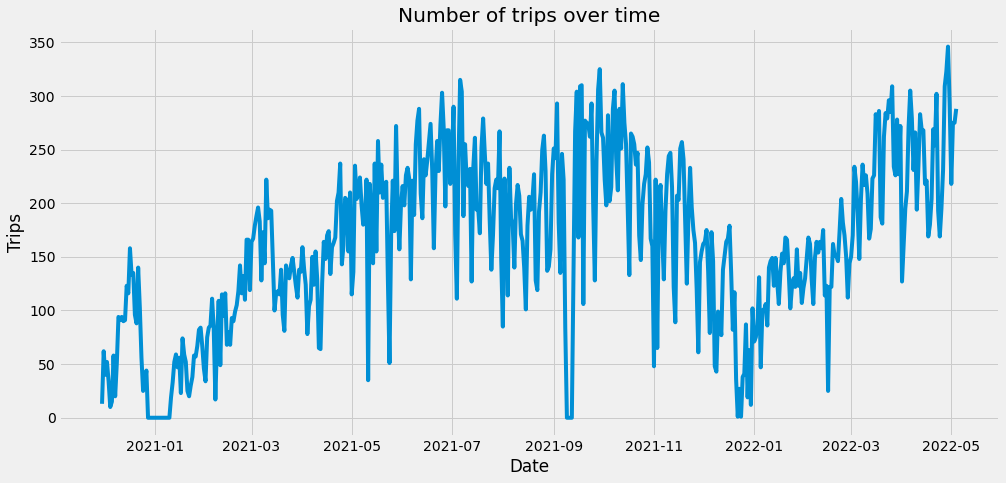

In [8]:
# Trend over time (count of trips oer day)
df['date'] = df.date_hour.dt.date
df_trend = df.groupby(['date']).aggregate({'trips_count':['sum']}).reset_index()
df_trend.columns = df_trend.columns.droplevel(1)
df_trend = df_trend.set_index(['date'])

plt.style.use('fivethirtyeight')

plt.figure(figsize=(15,7))
plt.title("Number of trips over time", color='black')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.plot(df_trend)
plt.show()

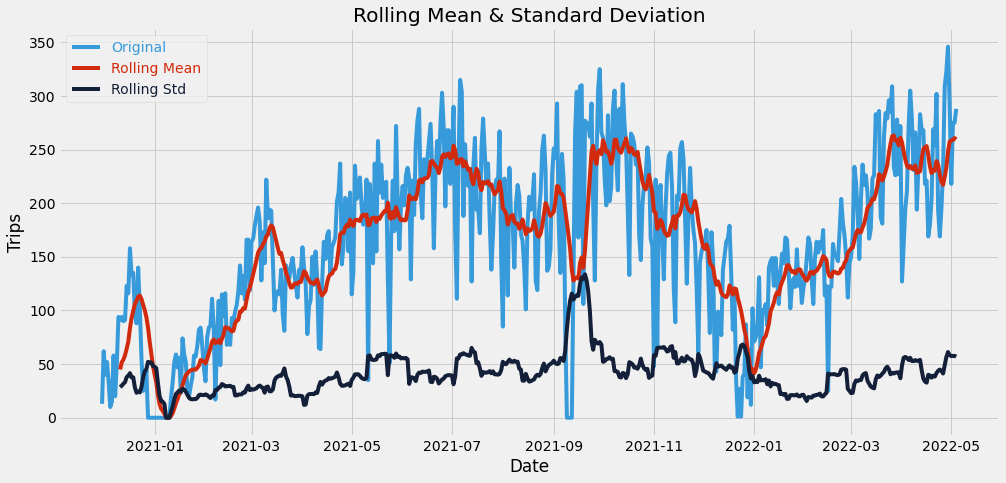

In [9]:
# Rolling statistics
# set window to 12 --> window size 12 denotes 12 months, giving rolling mean at yearly level
df_trend["rolling_avg"] = df_trend["trips_count"].rolling(window=12).mean() 
df_trend["rolling_std"] = df_trend["trips_count"].rolling(window=12).std()

plt.figure(figsize=(15,7))
plt.plot(df_trend["trips_count"], color='#379BDB', label='Original')
plt.plot(df_trend["rolling_avg"], color='#D22A0D', label='Rolling Mean')
plt.plot(df_trend["rolling_std"], color='#142039', label='Rolling Std')
plt.legend(loc='best', labelcolor='linecolor')
plt.title('Rolling Mean & Standard Deviation', color='black')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.show()

In [10]:
# drop date, and use date_hour column instead
df = df.drop(['date'], axis=1)

#### Augmented Dickey-Fuller Test
Check if data are stationary: they must be to fullfill ARIMA underlying hyphotesis; if they are not, differencing must be applied (**d** parameter).

In [11]:
# Augmented Dickey-Fuller Test: check if data is stationary (null-hp: not stationary)
# to reject the null hp, p-value <= 0.05
dftest = adfuller(df['trips_count'], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['ADF Test Statistic','p-value','Number of lags used','Number of observations used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
    
print(dfoutput)

ADF Test Statistic            -7.130664e+00
p-value                        3.524760e-10
Number of lags used            4.100000e+01
Number of observations used    1.244700e+04
Critical Value (1%)           -3.430875e+00
Critical Value (5%)           -2.861772e+00
Critical Value (10%)          -2.566894e+00
dtype: float64


Since the p-value is very low and below the significance level of 5% (p-value = 3.524760e-10), we can reject the null hyphotesis with high confidence and state that the data are probably stationary, which means we can apply the ARIMA model without any transformation.

Otherwise, transforming and differencing the data is needed to make it stationary; for example, one may take the square root transformation and then apply the *diff* function from *pandas*: 
```
df_transf = np.sqrt(df['trips_count'])
df_diff = df_transf.diff().dropna()
```
But overdifferencing may be an issue, since it can make the data not-stationary, thus the parameter *d* should be chosen carefully.

In order to find a suitable value for the q parameter, one could check the Auto-Correlation (ACF) plot.
Instead, to find the right *p* value, the Partial Autocorrelation (PACF) is used: with respect to Auto-Correlation, PACF removes the effect of intervening lags.

### Auto-Correlation

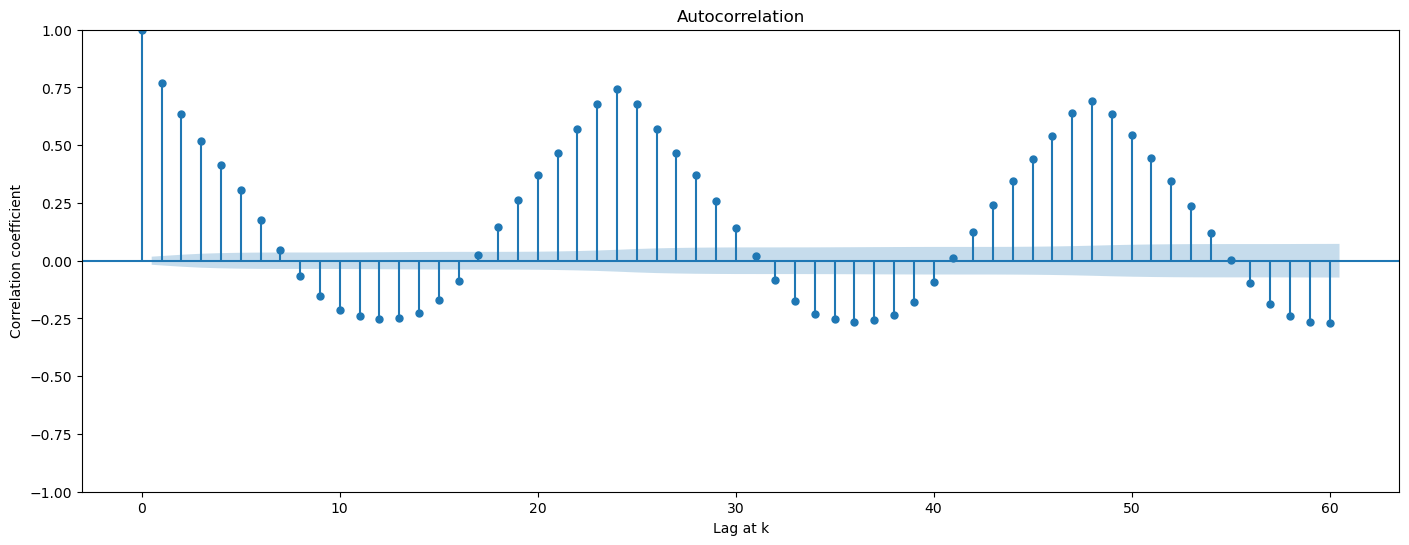

In [12]:
# Time Series Analysis Plots (tsaplots)
# Auto-Correlation Plot --> useful to find the value of q

plt.style.use('default')
rcParams["figure.figsize"] = 17, 6

fig = tsaplots.plot_acf(df["trips_count"], lags=60)

plt.xlabel("Lag at k")
plt.ylabel("Correlation coefficient")
plt.show()

Lags seems to remain above the significance line, thus start with setting q to a lower value in order to prefer simpler models.

**Plot description:**

The x-axis represent the lag number *k*, while the y-axis is the correlation coefficient at the variation of k. K represent the shifting value (e.g., when k=1, the correlation is found by shifting the series by 1). The strength of the influence of previous values on the current one is measured on a scale of -1 (perfect negative correlation) to 1 (perfect positive correlation) and it is shown on the y-axis.

The shaded region represents the confidence interval (default 5%), and if the bars are so high that they go outside this region, the correlation is said to be statistically significant. When there is a clear ***trend*** in the timeseries, the correlation coefficients tend to be high when k is small (small lags). Instead, when there is ***seasonality***, autocorrelation goes up periodically at larger values of k.

In this case there is a significant autocorrelation for small k, which means there is a trend in the timeseries. However, there seems to be also a clear seasonality in the data, given the sinusoidal shape of the ACF.
This suggests it may be useful to implement a Seasonal-ARIMA (SARIMA) to check if capturing the cyclical component helps in developing better models.

### Partial Auto-Correlation

c:\Users\luisa\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


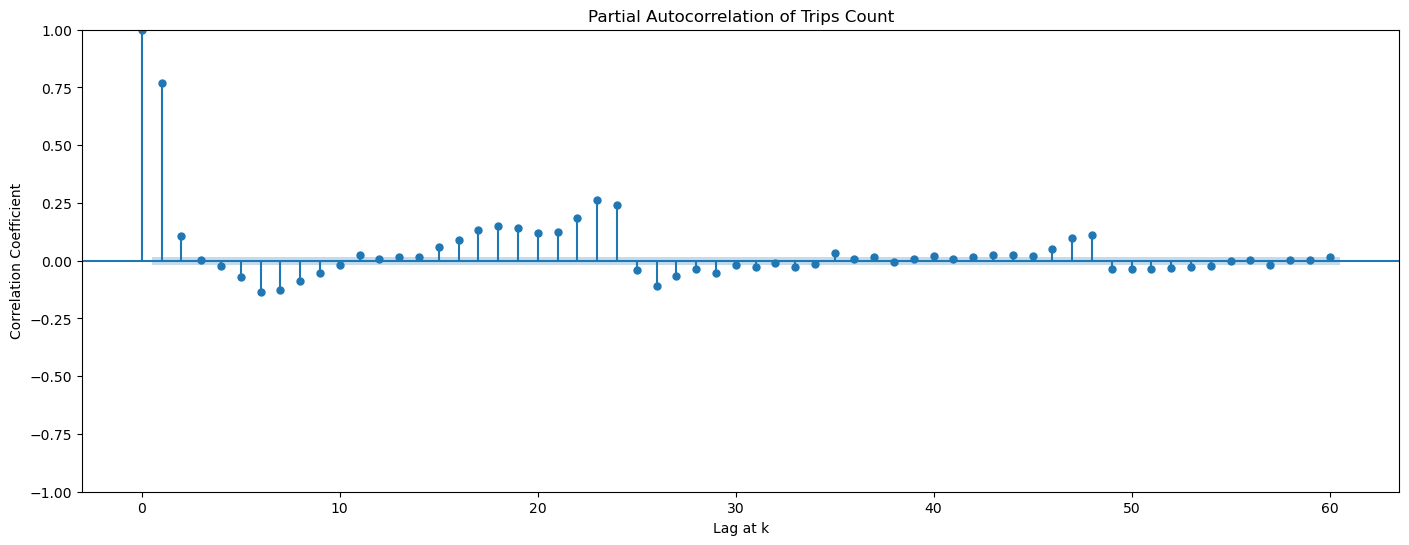

In [13]:
# PACF plot (not differenced data as they are already stationary) to find the value of p

fig = tsaplots.plot_pacf(df["trips_count"], lags=60)

plt.title("Partial Autocorrelation of Trips Count")
plt.xlabel("Lag at k")
plt.ylabel("Correlation Coefficient")
plt.show()

**Plot description:**

Partial autocorrelation differs from pure autocorrelation in the fact that it tries to account for the effect of intervening lags and to remove it (e.g., at lag 3, partial autocorrelation removes the effect lags 1 and 2 have on computing the correlation).

The autocorrelation for an observation and an observation at a prior time step comprehend both the direct correlation and the indirect correlations. These indirect correlations are a linear function of the correlation of the observation with the observations at intervening time steps. The partial autocorrelation aims to remove these indirect correlations. 

In this case, after taking out the inertia effect of the strong autocorrelation at low values of k, lags are significant from 1 to 3, as they are above the significance level of 5% (the small shaded region around the horizontal line). Then, the decreasing in significance is intense, with various oscillations and mostly non significant correlation coefficients, even though there exists few spikes going outside the confidence region at greater lags, which may be due to chance.

The analysis of the ACF and PACF helps us in setting the starting point for looking at the optimal values of q and p. The [*pmdarima*' auto_arima](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) method automatically finds the optimal order (d, p and q) for the ARIMA model, once it is given a minimum and maxium values of p and q (and a test to determine d, such as the Augmented Dickey-Fuller Test). The previous plot helped us understanding that a low value of q is plausible, thus the minimum is set to zero to prefer simpler models. For what concerns the order p, a value between 2 and 3 seems to be the most suitable, thus the minimum will be set to 2.